In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import operator_calculations as op_calc
import diffusion_maps as dmaps
import coarse_graining as cgm
import delay_embedding as embed
import simulation_functions as sim_funcs
import stats
import time

from scipy.sparse import csr_matrix
import deeptime.markov.tools.estimation as msm_estimation
import scipy.sparse as sp
from scipy.interpolate import CubicSpline

In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/FigS_3wellcg/'

In [3]:
from numba import jit,prange
from scipy.interpolate import PchipInterpolator

def get_potential(phen,der=False):
    N = 1000
    x_min, x_max = -2,2
    xsample = np.linspace(x_min, x_max, N)
    n_barriers = 2
    domain = [-2,2]
    max_spacing = (domain[1]-domain[0])/(n_barriers+1)
    n_minima = n_barriers+1
    min_locs = np.array([domain[0]+max_spacing/2 + k*max_spacing for k in range(n_minima)])
    max_locs = np.array([domain[0] + k*max_spacing for k in range(n_barriers+2)])
    
    max_heights = np.array([4,0,-0.75,4])

    mins = np.array(phen)
    min_heights = np.array(mins)
    x_all = np.hstack([max_locs,min_locs])
    y_all = np.hstack([max_heights,min_heights])
    sort = np.argsort(x_all)
    x_all = x_all[sort]
    y_all = y_all[sort]
    V = PchipInterpolator(x_all,y_all)

    if der == True:
        return V.derivative()
    else:
        return V

@jit(nopython=True, parallel=True)
def simulate_dw(x0s,params, x_range,tau_x, Tx, dt, max_iters,downsampling, drifts_lookup):
    n_sims = len(x0s)
    sims = np.zeros((n_sims, int(max_iters/downsampling)))
    n_grid = len(x_range)
    for ks in prange(n_sims):
        print(ks)
        param=params[ks]
        x0 = x0s[ks]
        x = x0
        for i in range(max_iters):
            drift = drifts_lookup[ks]
            idx = np.searchsorted(x_range, x)  # Find index
            if idx == 0:
                f = drift[0]
            elif idx >= n_grid:
                f = drift[-1]
            else:
                x1, x2 = x_range[idx-1], x_range[idx]
                f1, f2 = drift[idx-1], drift[idx]
                f = f1 + (f2 - f1) * (x - x1) / (x2 - x1)
            
            new_x = x - f * dt/tau_x + np.sqrt(2 * Tx*(1/tau_x)) * np.random.normal(0, np.sqrt(dt))
            x = new_x
            if i%downsampling==0:
                sims[ks, int(i/downsampling)] = x
    return sims

In [4]:
out_path = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/3well_pchip/'
f = h5py.File(out_path+'L_approx_metaData.h5','r')
labels_phen = np.array(f['labels_phen'])
phens = np.array(f['phens'])
Tx = np.array(f['Tx'])[0]
f.close()

In [5]:
Tx

0.5

In [6]:
Texp_range = np.array(np.logspace(2,4.0,11),dtype=int)
Texp_range = np.hstack([[10,17,31,56],Texp_range])
print(Texp_range)

[   10    17    31    56   100   158   251   398   630  1000  1584  2511
  3981  6309 10000]


In [7]:
dt = 0.01
Ti = 14
T = Texp_range[Ti]
print(T)
max_iter = int(T/dt)
final_dt = .05
ds = int(final_dt/dt)

x_inits = np.random.uniform(-1,1,len(phens))
max_iter = int(T/dt)

10000


In [8]:
drifts_lookup = []
x_grid = np.linspace(-2,2, 50000)
for i in range(len(phens)):
    param = phens[i]
    drifts_lookup.append(get_potential(param,der=True)(x_grid))
drifts_lookup = np.array(drifts_lookup)

sims = simulate_dw(x_inits, phens, x_grid, 1, Tx, dt, max_iter, 5, drifts_lookup)

058
35
5
50
74
40
30
10
66
25
86
94

45
15
54
82
20
78
90
102
70
62
98
1
36
41
26
31
91
87
75
71
63
59
6
95
16
79
51
103
55
11
21
83
67
2
99
37
46
42
27
32
7
92
88
72
76
64
60
96
17
3
80
104
56
22
84
68
100
4
52
38
28
43
33
8
12
9373

89
77
65
61
97
18
81
47
105
57
23
85
101
69
39
29
44
34
9
19
53
24
13
48
14
49


In [9]:
print(sims.shape)

(106, 200000)


0
1
2
3


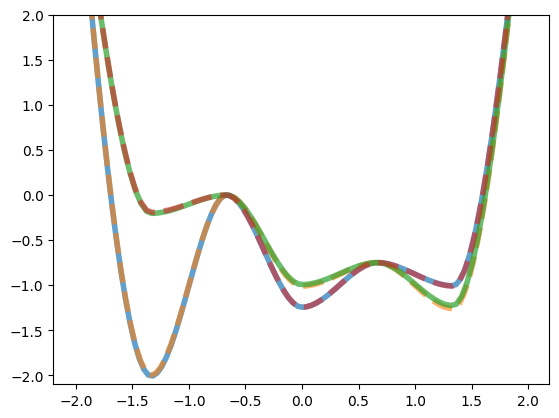

In [10]:
x_min, x_max = -2,2
xsample = np.linspace(x_min, x_max, 1000)
xsel = xsample

markers = ['o','d','*','^']
for i in np.unique(labels_phen):
    idx = np.where(labels_phen == i)[0]
    i = int(i)
    print(i)
    if i %2 == 0:
        plt.plot(xsel[::10+i],get_potential(phens[idx[5]])(xsel)[::10+i],lw=4,color='C{}'.format(int(i)), alpha=0.7)
    else:
        plt.plot(xsel[::10+i],get_potential(phens[idx[5]])(xsel)[::10+i],lw=4,ls='--',color='C{}'.format(int(i)), alpha=0.6)
plt.ylim(-2.1,2)
# plt.xlim(-1.1,1.1)
# plt.xlim(-1.2,1.2)
# plt.savefig(Fig_path+'3_well_pot_phens.pdf')
plt.show()

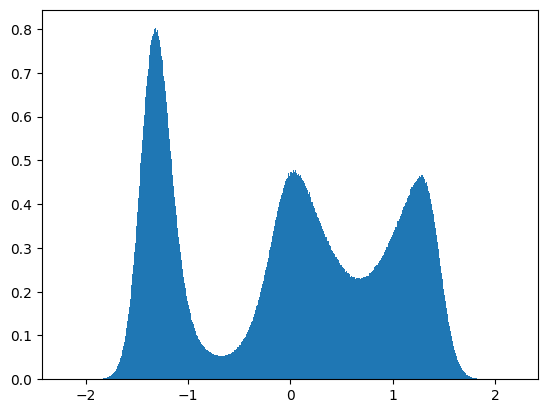

In [11]:
plt.hist(ma.hstack(sims),bins=1000,density=True)
plt.show()

In [12]:
sims = ma.array(sims)
sims[:,-1] = ma.masked

In [13]:
Ti = 10
T = Texp_range[Ti]
print(T)
trajs = sims.copy()
trajs = trajs[:,:int(T/final_dt)]
trajs[:,-1] = ma.masked

1584


In [14]:
print(trajs.shape)

(106, 31680)


In [15]:
# state_traj = embed.trajectory_matrix(all_fish_feats_,K=k)
n_clusters = 250
labels_all,centers = cl.kmeans_knn_partition(ma.hstack(trajs)[:,np.newaxis],n_seeds=n_clusters, return_centers=True)

labels_all[labels_all.mask] = n_clusters+100
labels_all[labels_all == n_clusters+100] = ma.masked

labels_recs = labels_all.reshape((trajs.shape[0],trajs.shape[1]))
labels_recs[:,-1] = ma.masked

In [16]:
print(labels_recs.shape)

(106, 31680)


In [17]:
to_mask = 350
np.random.seed(42)
seeds = np.random.randint(0,10000,20)
delay_range = np.arange(1,20,1)
dt = 0.05
sample_size= 20
n_modes=20
# to_mask = np.max(labels_recs.data)
# labels_recs[labels_recs == to_mask] = ma.masked
labels_all= ma.concatenate(labels_recs,axis=0)
# print(labels_fish.shape)

In [18]:
## Calculate implied timescales by sampling similar number of bouts from each condition

ts_traj_delay = ma.zeros((seeds.shape[0],len(delay_range),n_modes))
eigvals_shuffle = ma.zeros((seeds.shape[0],n_modes-1))

for i,s in enumerate(seeds):
    print(s)
    idx1 = np.random.choice(np.arange(labels_recs.shape[0]), sample_size, replace=False)
    labels_bootstrap = ma.concatenate([labels_recs[idx1]], axis=0)
    labels_ = ma.hstack(labels_bootstrap)
    nstates = ma.max(labels_) + 1
    segments = op_calc.segment_maskedArray(labels_)

    dtrajs = np.asarray([labels_[t0:tf] for t0,tf in segments],dtype=object)
    if ma.count(labels_)>20:
        for kd,delay in enumerate(delay_range):
            ts_traj_delay[i,kd,:] = op_calc.implied_tscale_shuffle(dtrajs,nstates,delay,dt,n_modes,reversible=True)
#     labels_shuffle = labels_[np.random.choice(np.arange(len(labels_)),len(labels_))]
#     P_shuffle = op_calc.transition_matrix(labels_shuffle,1)
    P_shuffle = op_calc.transition_matrix_shuffle(dtrajs,1)
    R_shuffle = op_calc.get_reversible_transition_matrix(P_shuffle)
    eigvals,eigvecs = op_calc.sorted_spectrum(R_shuffle,k=n_modes)
    sorted_indices = np.argsort(eigvals.real)[::-1]
    eigvals = eigvals[sorted_indices][1:].real
    eigvals[np.abs(eigvals-1)<1e-12] = np.nan
    eigvals[eigvals<1e-12] = np.nan
    eigvals_shuffle[i,:] = eigvals

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385


In [19]:
ts_traj_delay[ts_traj_delay==0] = ma.masked
eigvals_shuffle[eigvals_shuffle == 0] = ma.masked 

## Use if sampling similar number of bouts from each condition

ts_traj_delay_total = ts_traj_delay
eigvals_shuffle_total = eigvals_shuffle
print(ts_traj_delay_total.shape)
print(eigvals_shuffle_total.shape)

(20, 19, 20)
(20, 19)


/home/g/gautam-sridhar/miniforge3/envs/zilo/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


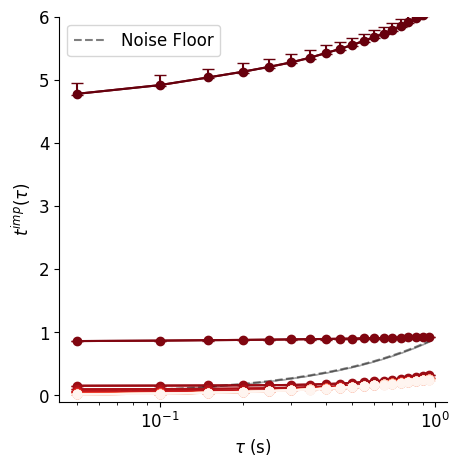

In [20]:
# Fig S2a - time scales for tau
colors_ = plt.cm.Reds_r(np.linspace(0,1,20))

fig, ax = plt.subplots(1,1,figsize=(5,5))
for mode in range(n_modes):
    mean = ma.mean(ts_traj_delay_total[:,:,mode],axis=0)
    cil = np.nanpercentile(ts_traj_delay_total[:,:,mode],2.5,axis=0)
    ciu = np.nanpercentile(ts_traj_delay_total[:,:,mode],97.5,axis=0)
    # mean,cil,ciu=stats.bootstrap(ts_traj_delay_total[:,:,mode].squeeze(),median=False,n_times=1000)
    ax.plot(delay_range*dt,mean,c=colors_[mode], marker='*')
    ax.errorbar(delay_range*dt, mean,[mean-cil, ciu - mean], marker='o', capsize=4, color = colors_[mode])

tscales_shuffle = np.array([-d*dt/np.log(eigvals_shuffle_total[:,0]) for d in delay_range])

mean = ma.mean(tscales_shuffle,axis=1)
cil = np.nanpercentile(tscales_shuffle,2.5,axis=1)
ciu = np.nanpercentile(tscales_shuffle,97.5,axis=1)


ax.plot(delay_range*dt,mean,c='k',alpha=.5,ls='--', label='Noise Floor')
ax.fill_between(delay_range*dt,cil,ciu,color='k',alpha=.3)
ax.legend(fontsize = 12)
ax.set_xlabel(r'$\tau$ (s)',fontsize=12)
ax.set_ylabel(r'$t^{imp} (\tau)$',fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xscale('log')
ax.set_ylim(-0.1,6.0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.savefig(Fig_path + 't_imp_tau.pdf')
plt.show()

In [21]:
print(tscales_shuffle.shape)

(19, 20)


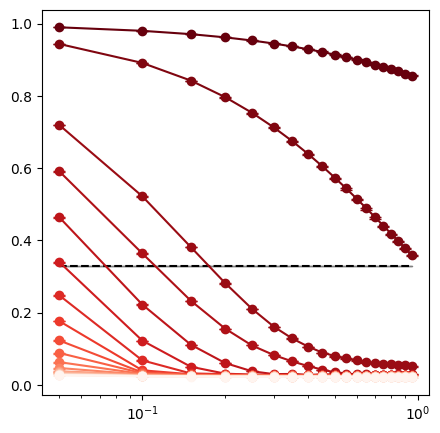

In [22]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
for mode in range(n_modes):
    mean = ma.mean(ts_traj_delay_total[:,:,mode],axis=0)
    cil = np.nanpercentile(ts_traj_delay_total[:,:,mode],2.5,axis=0)
    ciu = np.nanpercentile(ts_traj_delay_total[:,:,mode],97.5,axis=0)
    # ax.plot(delay_range*dt,np.exp((-delay_range*dt)/mean),c=colors_[mode], marker='*')
    ax.errorbar(delay_range*dt, np.exp((-delay_range*dt)/mean),[np.exp((-delay_range*dt)/mean)-np.exp((-delay_range*dt)/cil), np.exp((-delay_range*dt)/ciu) - np.exp((-delay_range*dt)/mean)], 
                marker='o', capsize=4, color = colors_[mode])
# mean,cil,ciu=stats.bootstrap((eigvals_shuffle_total[:,0]),n_times=1000)
mean = ma.mean(eigvals_shuffle_total[:,0])
cil = np.nanpercentile(eigvals_shuffle_total[:,0],2.5,axis=0)
ciu = np.nanpercentile(eigvals_shuffle_total[:,0],97.5,axis=0)
ax.plot(delay_range*dt,mean*np.ones((len(delay_range))),ls='--',c='k')
ax.fill_between(delay_range*dt,cil*np.ones((len(delay_range))),ciu*np.ones((len(delay_range))),color='k', alpha=0.5)
# plt.xlim(0,6)
# plt.yscale('log')
ax.set_xscale('log')
# plt.savefig(Fig_path + 'eigvals_tau.pdf')

(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.]),
 [Text(0, -1.0, '−1'),
  Text(0, 0.0, '0'),
  Text(0, 1.0, '1'),
  Text(0, 2.0, '2'),
  Text(0, 3.0, '3'),
  Text(0, 4.0, '4'),
  Text(0, 5.0, '5'),
  Text(0, 6.0, '6')])

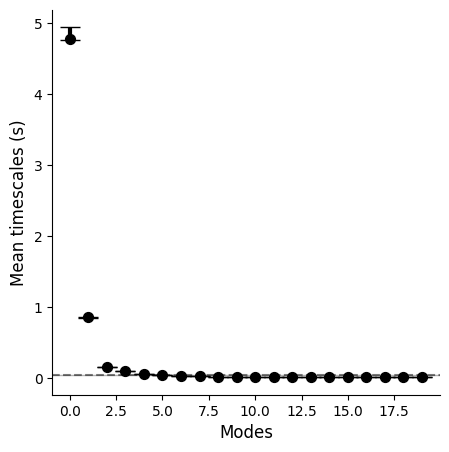

In [23]:
# Fig 2a 
fig, ax = plt.subplots(1,1,figsize=(5,5))

tau = 1


ts_traj_delay1 = ts_traj_delay_total[:,tau-1,:]
mean,cil,ciu=stats.bootstrap(ts_traj_delay1[:,:],median=False,n_times=1000)

mean = ma.mean(ts_traj_delay1,axis=0)
cil = np.nanpercentile(ts_traj_delay1,2.5,axis=0)
ciu = np.nanpercentile(ts_traj_delay1,97.5,axis=0)

ax.scatter(np.arange(n_modes),mean,c='k', s =50)
ax.errorbar(np.arange(n_modes), mean,[mean-cil, ciu - mean], fmt='.', capsize=7, elinewidth=3, color = 'k')


tscales_shuffle = np.array([-d*dt/np.log(eigvals_shuffle_total[:,0]) for d in delay_range])
mean = ma.mean(tscales_shuffle,axis=1)
cil = np.nanpercentile(tscales_shuffle,2.5,axis=1)
ciu = np.nanpercentile(tscales_shuffle,97.5,axis=1)
ax.axhline(mean[tau-1],c='k',alpha=.5,ls='--', label='Noise Floor')
ax.axhspan(cil[tau-1],ciu[tau-1],color='k',alpha=.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Modes',fontsize=12)
ax.set_ylabel('Mean timescales (s)',fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.savefig(Fig_path+'t_imp_tau1.pdf')

In [24]:
import deeptime.markov.tools.estimation as msm_estimation
from scipy.sparse import diags,identity,coo_matrix, csr_matrix

delay = 1
dt = 0.05
print(delay)

segments = op_calc.segment_maskedArray(labels_all)
dtrajs = np.asarray([labels_all[t0:tf] for t0,tf in segments],dtype=object)
# P_ensemble = csr_matrix(P_ensemble)
lcs_ensemble,P_ensemble = op_calc.transition_matrix(dtrajs,delay,return_connected=True)
lcs_ensemble = msm_estimation.largest_connected_set(P_ensemble)

inv_measure = op_calc.stationary_distribution(P_ensemble)
final_labels = op_calc.get_connected_labels(labels_all,lcs_ensemble)
R = op_calc.get_reversible_transition_matrix(P_ensemble)
eigvals,eigvecs = op_calc.sorted_spectrum(R,k=10,seed=123) 
sorted_indices = np.argsort(eigvals.real)[::-1]
eigvals = eigvals[sorted_indices][1:].real
eigvals[np.abs(eigvals-1)<1e-12] = np.nan
eigvals[eigvals<1e-12] = np.nan
t_imp =  -(delay*dt)/np.log(np.abs(eigvals))
eigfunctions = eigvecs.real#/np.linalg.norm(eigvecs.real,axis=0)
eigfunctions_traj = ma.array(eigfunctions)[final_labels,:]
eigfunctions_traj[final_labels.mask] = ma.masked

1


In [25]:
print(len(lcs_ensemble))

250


In [26]:
phi1 = eigfunctions[:,1]
phi2 = eigfunctions[:,2]
phi3 = eigfunctions[:,3]
phi4 = eigfunctions[:,4]

In [28]:
import skfuzzy as fuzz
from sklearn.cluster import KMeans
kinetic_dists = eigfunctions[:,1:3]*eigvals[:2]
X = kinetic_dists

In [29]:
np.random.seed(42)
seeds = np.random.randint(0,10000,1000)
min_rhos = []
q = 2
for s in seeds:
    print(s)
    kmeans = KMeans(n_clusters=q, random_state=s,n_init=1).fit(X,sample_weight=inv_measure)
    ha = kmeans.labels_
    rho_sets = [(inv_measure[ha==idx]@(P_ensemble[ha==idx,:][:,ha==idx])).sum()/inv_measure[ha==idx].sum()
                          for idx in np.unique(ha)]
    min_rhos.append(np.median(rho_sets))
s = seeds[np.where(min_rhos == np.max(min_rhos))[0]]
kmeans = KMeans(n_clusters=q, random_state=s[0] ,n_init=1).fit(X,sample_weight=inv_measure)
# cr, centers, labels = weighted_fuzzy_cmeans(X,n_clusters=2,weights=inv_measure,m=1.2)
# hard_assign = np.argmax(cr,axis=0)

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385
6396
8666
9274
2558
7849
2047
2747
9167
9998
189
2734
3005
4658
1899
7734
1267
1528
3556
3890
8838
5393
8792
8433
7513
2612
7041
9555
6235
5486
7099
9670
775
8226
3152
1585
3943
7555
3073
1021
3843
7989
9692
6873
5675
161
4297
995
7629
9467
1016
7869
6439
7892
6863
7916
8529
878
9268
4887
4859
6331
8571
8684
7208
5276
2062
64
8006
2568
5463
2027
2695
9687
5258
5618
6736
391
5892
3561
6184
3099
6278
8392
3104
7215
2454
8996
2731
8154
9762
5056
8110
3840
1028
7385
502
6910
9062
6938
4488
206
5134
5977
7721
7035
1484
7858
863
2790
7408
8755
5116
6019
1757
7574
6374
6892
1678
3242
4636
1059
6668
9914
3157
5915
9789
2693
3627
9555
5450
1663
9721
5592
7392
1306
6776
5864
9474
7526
8901
5575
5530
4413
3748
663
1998
7994
1495
3304
3763
5232
1853
6585
1291
3581
7554
7280
1636
3696
698
4737
854
8164
5855
7392
6528
5249
5172
1707
5791
9925
5535
4931
3510
202
4218
8958
4389
2327
8004
2931
7777
197
7125

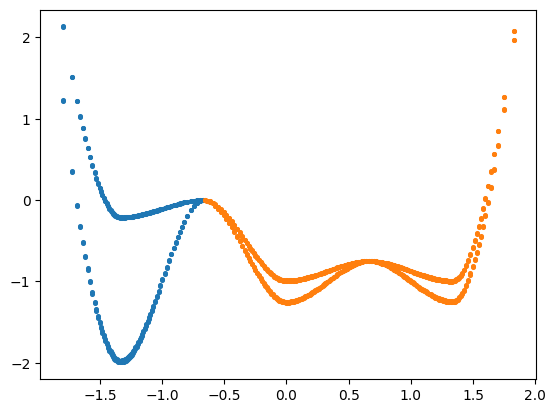

In [30]:
ha =kmeans.labels_
for i in np.unique(ha):
    plt.scatter(centers[ha==i],get_potential(phens[0])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[25])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[54])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[78])(centers[ha==i]),s=7,c='C{}'.format(i))
# plt.savefig(Fig_path+'3well_pot_cg6.pdf')
plt.show()

In [31]:
np.random.seed(42)
seeds = np.random.randint(0,10000,1000)
min_rhos = []
q = 3
for s in seeds:
    print(s)
    kmeans = KMeans(n_clusters=q, random_state=s,n_init=1).fit(X,sample_weight=inv_measure)
    ha = kmeans.labels_
    rho_sets = [(inv_measure[ha==idx]@(P_ensemble[ha==idx,:][:,ha==idx])).sum()/inv_measure[ha==idx].sum()
                          for idx in np.unique(ha)]
    min_rhos.append(np.median(rho_sets))
s = seeds[np.where(min_rhos == np.max(min_rhos))[0]]
kmeans = KMeans(n_clusters=q, random_state=s[0] ,n_init=1).fit(X,sample_weight=inv_measure)
# cr, centers, labels = weighted_fuzzy_cmeans(X,n_clusters=2,weights=inv_measure,m=1.2)
# hard_assign = np.argmax(cr,axis=0)

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385
6396
8666
9274
2558
7849
2047
2747
9167
9998
189
2734
3005
4658
1899
7734
1267
1528
3556
3890
8838
5393
8792
8433
7513
2612
7041
9555
6235
5486
7099
9670
775
8226
3152
1585
3943
7555
3073
1021
3843
7989
9692
6873
5675
161
4297
995
7629
9467
1016
7869
6439
7892
6863
7916
8529
878
9268
4887
4859
6331
8571
8684
7208
5276
2062
64
8006
2568
5463
2027
2695
9687
5258
5618
6736
391
5892
3561
6184
3099
6278
8392
3104
7215
2454
8996
2731
8154
9762
5056
8110
3840
1028
7385
502
6910
9062
6938
4488
206
5134
5977
7721
7035
1484
7858
863
2790
7408
8755
5116
6019
1757
7574
6374
6892
1678
3242
4636
1059
6668
9914
3157
5915
9789
2693
3627
9555
5450
1663
9721
5592
7392
1306
6776
5864
9474
7526
8901
5575
5530
4413
3748
663
1998
7994
1495
3304
3763
5232
1853
6585
1291
3581
7554
7280
1636
3696
698
4737
854
8164
5855
7392
6528
5249
5172
1707
5791
9925
5535
4931
3510
202
4218
8958
4389
2327
8004
2931
7777
197
7125

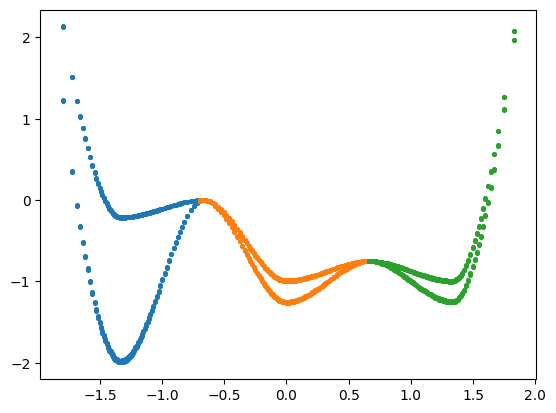

In [32]:
ha =kmeans.labels_
for i in np.unique(ha):
    plt.scatter(centers[ha==i],get_potential(phens[0])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[25])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[54])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[78])(centers[ha==i]),s=7,c='C{}'.format(i))
# plt.savefig(Fig_path+'3well_pot_cg6.pdf')
plt.show()

In [33]:
np.random.seed(42)
seeds = np.random.randint(0,10000,1000)
min_rhos = []
q = 4
for s in seeds:
    print(s)
    kmeans = KMeans(n_clusters=q, random_state=s,n_init=1).fit(X,sample_weight=inv_measure)
    ha = kmeans.labels_
    rho_sets = [(inv_measure[ha==idx]@(P_ensemble[ha==idx,:][:,ha==idx])).sum()/inv_measure[ha==idx].sum()
                          for idx in np.unique(ha)]
    min_rhos.append(np.median(rho_sets))
s = seeds[np.where(min_rhos == np.max(min_rhos))[0]]
kmeans = KMeans(n_clusters=q, random_state=s[0] ,n_init=1).fit(X,sample_weight=inv_measure)
# cr, centers, labels = weighted_fuzzy_cmeans(X,n_clusters=2,weights=inv_measure,m=1.2)
# hard_assign = np.argmax(cr,axis=0)

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385
6396
8666
9274
2558
7849
2047
2747
9167
9998
189
2734
3005
4658
1899
7734
1267
1528
3556
3890
8838
5393
8792
8433
7513
2612
7041
9555
6235
5486
7099
9670
775
8226
3152
1585
3943
7555
3073
1021
3843
7989
9692
6873
5675
161
4297
995
7629
9467
1016
7869
6439
7892
6863
7916
8529
878
9268
4887
4859
6331
8571
8684
7208
5276
2062
64
8006
2568
5463
2027
2695
9687
5258
5618
6736
391
5892
3561
6184
3099
6278
8392
3104
7215
2454
8996
2731
8154
9762
5056
8110
3840
1028
7385
502
6910
9062
6938
4488
206
5134
5977
7721
7035
1484
7858
863
2790
7408
8755
5116
6019
1757
7574
6374
6892
1678
3242
4636
1059
6668
9914
3157
5915
9789
2693
3627
9555
5450
1663
9721
5592
7392
1306
6776
5864
9474
7526
8901
5575
5530
4413
3748
663
1998
7994
1495
3304
3763
5232
1853
6585
1291
3581
7554
7280
1636
3696
698
4737
854
8164
5855
7392
6528
5249
5172
1707
5791
9925
5535
4931
3510
202
4218
8958
4389
2327
8004
2931
7777
197
7125

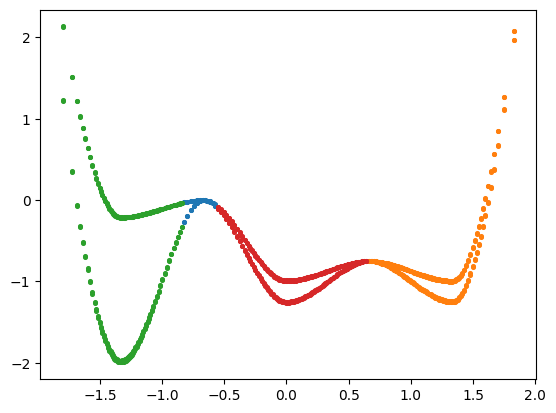

In [34]:
ha =kmeans.labels_
for i in np.unique(ha):
    plt.scatter(centers[ha==i],get_potential(phens[0])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[25])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[54])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[78])(centers[ha==i]),s=7,c='C{}'.format(i))
# plt.savefig(Fig_path+'3well_pot_cg6.pdf')
plt.show()

In [35]:
np.random.seed(42)
seeds = np.random.randint(0,10000,1000)
min_rhos = []
q = 5
for s in seeds:
    print(s)
    kmeans = KMeans(n_clusters=q, random_state=s,n_init=1).fit(X,sample_weight=inv_measure)
    ha = kmeans.labels_
    rho_sets = [(inv_measure[ha==idx]@(P_ensemble[ha==idx,:][:,ha==idx])).sum()/inv_measure[ha==idx].sum()
                          for idx in np.unique(ha)]
    min_rhos.append(np.median(rho_sets))
s = seeds[np.where(min_rhos == np.max(min_rhos))[0]]
kmeans = KMeans(n_clusters=q, random_state=s[0] ,n_init=1).fit(X,sample_weight=inv_measure)
# cr, centers, labels = weighted_fuzzy_cmeans(X,n_clusters=2,weights=inv_measure,m=1.2)
# hard_assign = np.argmax(cr,axis=0)

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385
6396
8666
9274
2558
7849
2047
2747
9167
9998
189
2734
3005
4658
1899
7734
1267
1528
3556
3890
8838
5393
8792
8433
7513
2612
7041
9555
6235
5486
7099
9670
775
8226
3152
1585
3943
7555
3073
1021
3843
7989
9692
6873
5675
161
4297
995
7629
9467
1016
7869
6439
7892
6863
7916
8529
878
9268
4887
4859
6331
8571
8684
7208
5276
2062
64
8006
2568
5463
2027
2695
9687
5258
5618
6736
391
5892
3561
6184
3099
6278
8392
3104
7215
2454
8996
2731
8154
9762
5056
8110
3840
1028
7385
502
6910
9062
6938
4488
206
5134
5977
7721
7035
1484
7858
863
2790
7408
8755
5116
6019
1757
7574
6374
6892
1678
3242
4636
1059
6668
9914
3157
5915
9789
2693
3627
9555
5450
1663
9721
5592
7392
1306
6776
5864
9474
7526
8901
5575
5530
4413
3748
663
1998
7994
1495
3304
3763
5232
1853
6585
1291
3581
7554
7280
1636
3696
698
4737
854
8164
5855
7392
6528
5249
5172
1707
5791
9925
5535
4931
3510
202
4218
8958
4389
2327
8004
2931
7777
197
7125

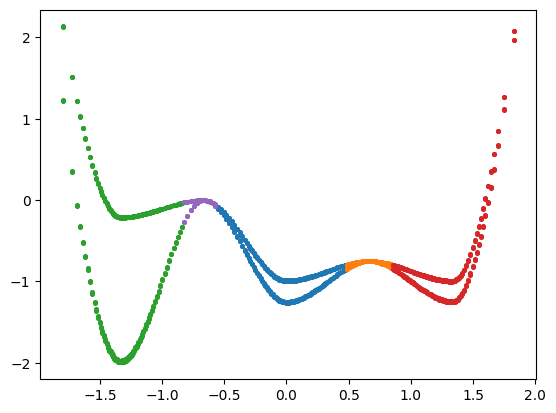

In [36]:
ha =kmeans.labels_
for i in np.unique(ha):
    plt.scatter(centers[ha==i],get_potential(phens[0])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[25])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[54])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[78])(centers[ha==i]),s=7,c='C{}'.format(i))
# plt.savefig(Fig_path+'3well_pot_cg6.pdf')
plt.show()

In [37]:
np.random.seed(42)
seeds = np.random.randint(0,10000,1000)
min_rhos = []
q = 6
for s in seeds:
    print(s)
    kmeans = KMeans(n_clusters=q, random_state=s,n_init=1).fit(X,sample_weight=inv_measure)
    ha = kmeans.labels_
    rho_sets = [(inv_measure[ha==idx]@(P_ensemble[ha==idx,:][:,ha==idx])).sum()/inv_measure[ha==idx].sum()
                          for idx in np.unique(ha)]
    min_rhos.append(np.median(rho_sets))
s = seeds[np.where(min_rhos == np.max(min_rhos))[0]]
kmeans = KMeans(n_clusters=q, random_state=s[0] ,n_init=1).fit(X,sample_weight=inv_measure)
# cr, centers, labels = weighted_fuzzy_cmeans(X,n_clusters=2,weights=inv_measure,m=1.2)
# hard_assign = np.argmax(cr,axis=0)

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385
6396
8666
9274
2558
7849
2047
2747
9167
9998
189
2734
3005
4658
1899
7734
1267
1528
3556
3890
8838
5393
8792
8433
7513
2612
7041
9555
6235
5486
7099
9670
775
8226
3152
1585
3943
7555
3073
1021
3843
7989
9692
6873
5675
161
4297
995
7629
9467
1016
7869
6439
7892
6863
7916
8529
878
9268
4887
4859
6331
8571
8684
7208
5276
2062
64
8006
2568
5463
2027
2695
9687
5258
5618
6736
391
5892
3561
6184
3099
6278
8392
3104
7215
2454
8996
2731
8154
9762
5056
8110
3840
1028
7385
502
6910
9062
6938
4488
206
5134
5977
7721
7035
1484
7858
863
2790
7408
8755
5116
6019
1757
7574
6374
6892
1678
3242
4636
1059
6668
9914
3157
5915
9789
2693
3627
9555
5450
1663
9721
5592
7392
1306
6776
5864
9474
7526
8901
5575
5530
4413
3748
663
1998
7994
1495
3304
3763
5232
1853
6585
1291
3581
7554
7280
1636
3696
698
4737
854
8164
5855
7392
6528
5249
5172
1707
5791
9925
5535
4931
3510
202
4218
8958
4389
2327
8004
2931
7777
197
7125

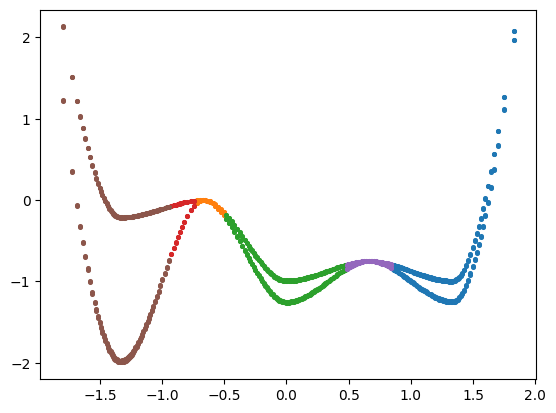

In [38]:
ha =kmeans.labels_
for i in np.unique(ha):
    plt.scatter(centers[ha==i],get_potential(phens[0])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[25])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[54])(centers[ha==i]),s=7,c='C{}'.format(i))
    plt.scatter(centers[ha==i],get_potential(phens[78])(centers[ha==i]),s=7,c='C{}'.format(i))
# plt.savefig(Fig_path+'3well_pot_cg6.pdf')
plt.show()